HOMEWORK 2

LUCA NICOLOSI 1000047978

In [2]:
# Importing librares 

import pandas as pd

import matplotlib.pyplot as plt

import numpy as np

import yfinance as yf 


In [3]:
# STEP 0

df_full = pd.read_csv('Symbol_Info_extended_2.csv', sep=';', encoding='latin1') # I'm importing the dataset. With sep I'm specifing that each column is separated by a semicolon, while econding allow me to avoind problems with accents.

countries = ['Ireland', 'Italy', 'Germany', 'Netherlands', 'Luxembourg', 'Spain', 'France'] # I'm creating a list which includes all the countries which belong to group 5

df_filtered_group5 = df_full[df_full['country'].isin(countries)].copy()# I'm filtering the dataset by considering only the companies located in the selected countries

selected_symbol = 'STM'

company_info = df_filtered_group5[df_filtered_group5['symbol'] == selected_symbol]

print(company_info)


     symbol             company_name      sector        industry      country  \
2595    STM  STMicroelectronics N.V.  Technology  Semiconductors  Netherlands   

        market_cap   net_income  total_revenue  return_on_assets  \
2595  5.942478e+10  147000000.0   1.237800e+10           0.01523   

      return_on_equity  ...  pe_trailing  pe_forward  earnings_growth  \
2595           0.00908  ...      417.875   29.982063           -333.0   

      price_to_sales  price_to_book  revenue_growth  debt_to_equity  \
2595        4.800838       3.344505            0.23          15.316   

      dividend_yield  payout_ratio  free_cashflow  
2595            0.54          2.25   -360500000.0  

[1 rows x 21 columns]


The reasons why I selected STMicroelectronics are based on its market capitalization of 59.42 billion, which provides a high-scale anchor for European peer analysis. 

Despite a cyclical downturn compressing its Return on Assets to 1.52% and Return on Equity to 0.91%, its revenue growth remains resilient at +23%. This operational disconnect explains the highly distorted trailing P/E of 417.88x compared to a forward P/E of 29.98x, signaling market expectations of a cyclical recovery. 

Furthermore, its conservative Debt-to-Equity ratio of 15.32% allows the company to fund heavy capital investments, directly explaining the temporary negative Free Cash Flow of -$360.5 million.

In [4]:
# STEP 1

required_var = ['symbol', 'company_name', 'sector', 'industry', 'country', 'market_cap',
    'return_on_assets', 'return_on_equity', 'profit_margins',
    'pe_trailing', 'price_to_book', 'revenue_growth', 'debt_to_equity', 'free_cashflow'] # I'm creating a list containing the name of all the requierd variables

df_clean = df_full[required_var].copy() # I'm creating a new dataset which includes just the required variables 

df_clean.replace([np.inf, -np.inf], np.nan, inplace=True) # I'm substituting infinite values with nan values

df_clean = df_clean[df_clean['market_cap'] > 0] # I'm filtering the dataset by excluding the companies with a non-positive market capitalization

df_clean.loc[df_clean['pe_trailing']<= 0, 'pe_trailing'] = np.nan # I'm substituting the negative values of the pe_trailing variable with nan values 
df_clean.loc[df_clean['price_to_book'] <= 0, 'price_to_book'] = np.nan # I'm substituting the negative values of the price_to_book variable with nan values

df_clean[df_clean['symbol'] == 'STM']


,symbol,company_name,sector,industry,country,market_cap,return_on_assets,return_on_equity,profit_margins,pe_trailing,price_to_book,revenue_growth,debt_to_equity,free_cashflow
2595,STM,STMicroelectronics N.V.,Technology,Semiconductors,Netherlands,5.942478e+10,0.01523,0.00908,0.01188,417.875,3.344505,0.23,15.316,-360500000.0


In [ ]:
# STEP 2

target_company = df_clean[df_clean['symbol'] == selected_symbol].iloc[0] # In the cleaned dataset I'm selecting the entire first row where the symbol is equal to STM. 

target_industry = target_company['industry'] # I'm storing in a variable the industry of the selected company

target_cap = target_company['market_cap'] # I'm storing in a variable the market capitalization of the selected company

df_clean['plot_label'] = df_clean['company_name'].fillna(df_clean['symbol'])

# GROUP A: SAME INDUSTRY 

group_a_pool = df_clean[df_clean['industry'] == target_industry] # I'm selecting from the cleaned dataset all the companies with the same industry of the selected one

group_a = group_a_pool.sort_values(by = 'market_cap', ascending= False).head(10).copy()# I'm sorting the companies by the market capitalization in a decreasing way and the I consider just the first 10

if selected_symbol not in group_a['symbol'].values:
    group_a = pd.concat([group_a, df_clean[df_clean['symbol']== selected_symbol]]) # I'm manually andding the selected company if it does not appear among the first 10 with the highest market capitalization


# GROUP B: SAME GEOGRAPHIC GROUP (EUROPE)

group_b_pool = df_clean[df_clean['country'].isin(countries)] # I'm selecting all the companies located in Europe

group_b = group_b_pool.sort_values(by ='market_cap', ascending = False).head(10).copy() # I'm sorting the companies by the market capitalization in a decreasing way and the I consider just the first 10

if selected_symbol not in group_b['symbol'].values:
    group_b = pd.concat([group_b, df_clean[df_clean['symbol'] == selected_symbol]] ) # I'm manually andding the selected company if it does not appear among the first 10 with the highest market capitalization


# GROUP C: CLOSEST MARKET CAPITALIZATION

df_c_pool = df_clean.copy() # I'm creating a new data frame equal to the original cleaned one

df_c_pool['cap_distance'] = (df_c_pool['market_cap'] - target_cap).abs() # I'm adding a new variables which includes the differences between the market capitalization of the original company and the market capitalization of all the others

group_c = df_c_pool.sort_values(by = 'cap_distance').head(10).copy() # I'm considering the first 10 companies with the clostest market capatalization to the one of the selected company

--- GENERATING PROFIT MARGINS CHARTS ---


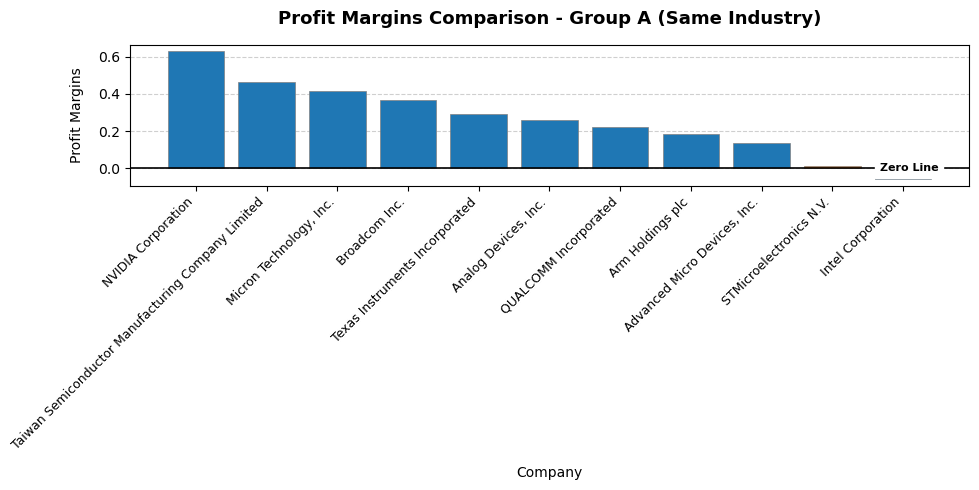

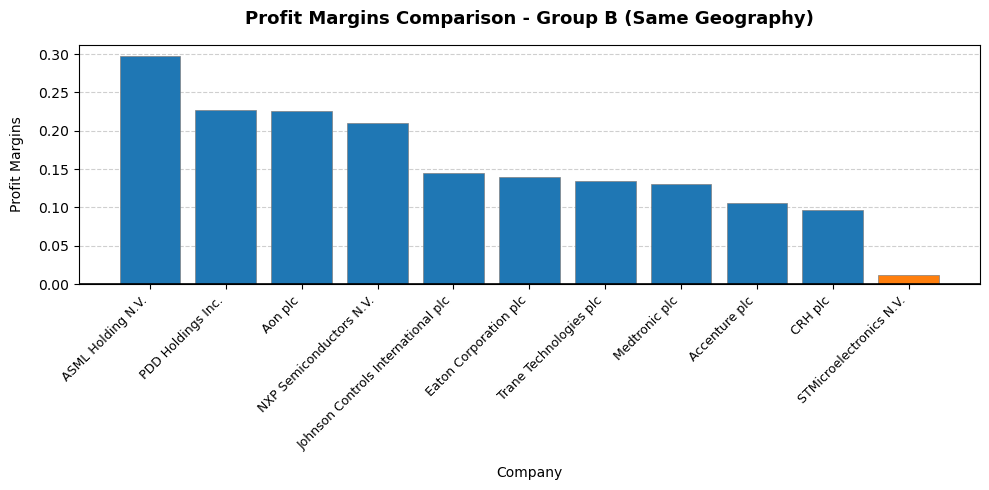

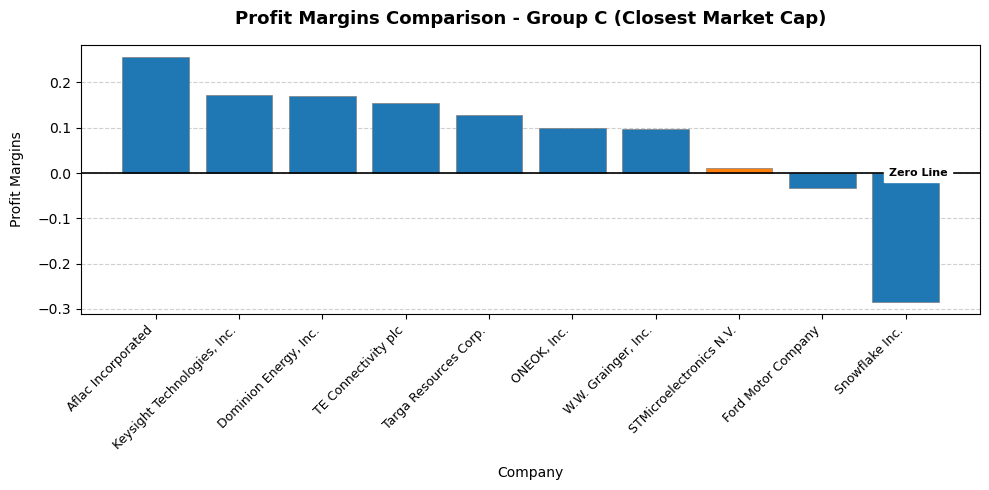


--- GENERATING RETURN ON EQUITY (ROE) CHARTS ---


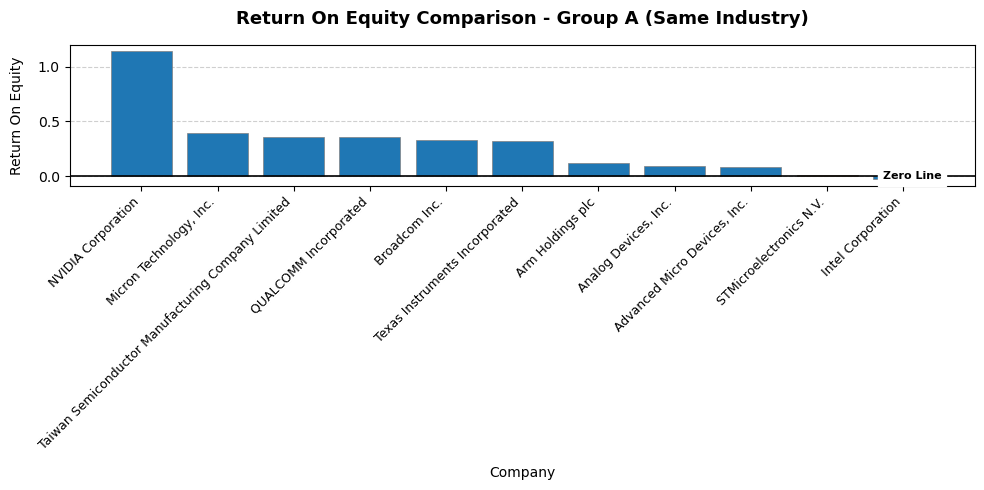

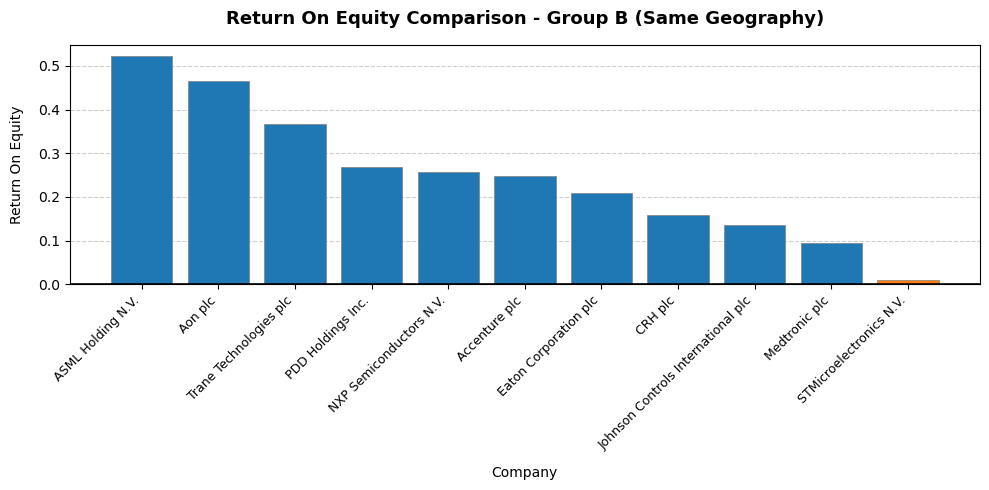

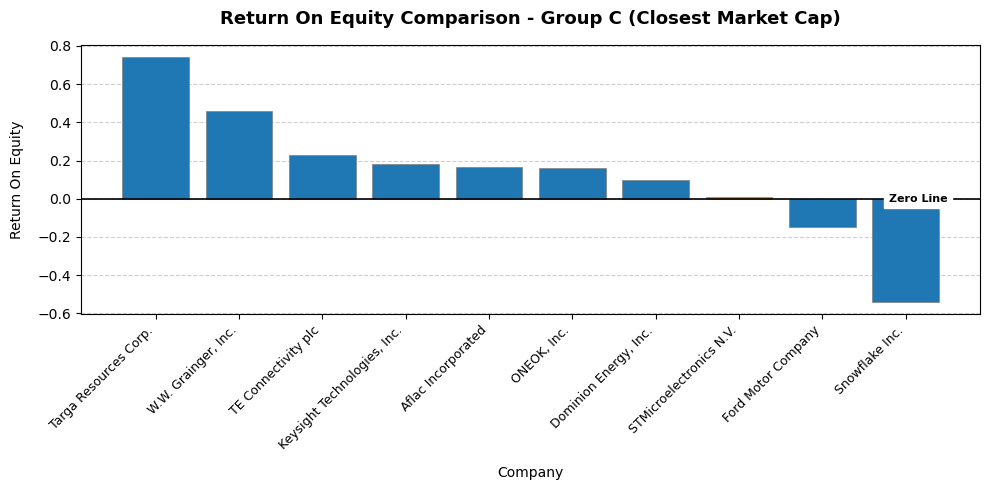

In [12]:
# STEP 3

def plot_profitability(df_group, metric_name, group_title): # I'm creating a function for genereting the plots in order avoid repetitions 
    
    df_plot = df_group.dropna(subset= [metric_name]).copy() # I'm removing the missing data for the analyzed metrics 

    df_plot = df_plot.sort_values(by= metric_name, ascending = False) # I'm ordering in a decriesing way by the analyzed metric

    # I'm extraxting the data contained in the data frame and I'm including them in separated lists
    labels = df_plot['plot_label'].tolist()
    symbols = df_plot['symbol'].tolist()
    values = df_plot[metric_name].tolist()
     
    group_median = df_plot[metric_name].median() # I'm computing the median of the group

    colors = ['#ff7f0e' if sym == 'STM' else '#1f77b4' for sym in symbols] # I'm setting the colors of the bars. Orange is for the selected company, blue for the others. 

    fig, ax = plt.subplots(figsize = (10, 5))

    bars = ax.bar(labels, values, color = colors, edgecolor = 'grey', linewidth = 0.5) # I'm defining the bars 
    
    # I'm setting the title and the labels of the axes 
    metric_label = metric_name.replace('_', ' ').title()
    ax.set_title(f'{metric_label} Comparison - {group_title}', fontsize= 13, fontweight = 'bold', pad = 15)
    ax.set_xlabel('Company', fontsize = 10, labelpad = 10)
    ax.set_ylabel(metric_label, fontsize = 10, labelpad=10)

    # Format X-axis ticks and labels dynamically to prevent rendering warnings and avoid text overlap.
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation = 45, ha = 'right', fontsize = 9)

    # I'm generating the grid 
    ax.yaxis.grid(True, linestyle = '--', alpha = 0.6)
    ax.set_axisbelow(True)

    # Create and label the zero reference line if the dataset contains negative values
    ax.axhline(0, color = 'black', linestyle = '-', linewidth = 1.2)
    if min(values) < 0:
        ax.text(len(labels)-0.5, 0, 'Zero Line', color = 'black', va = 'center', ha = 'right', backgroundcolor = 'white', fontsize = 8, fontweight = 'bold')

    plt.tight_layout()
    plt.show()


print("--- GENERATING PROFIT MARGINS CHARTS ---")
plot_profitability(group_a, 'profit_margins', "Group A (Same Industry)")
plot_profitability(group_b, 'profit_margins', "Group B (Same Geography)")
plot_profitability(group_c, 'profit_margins', "Group C (Closest Market Cap)")


print("\n--- GENERATING RETURN ON EQUITY (ROE) CHARTS ---")
plot_profitability(group_a, 'return_on_equity', "Group A (Same Industry)")
plot_profitability(group_b, 'return_on_equity', "Group B (Same Geography)")
plot_profitability(group_c, 'return_on_equity', "Group C (Closest Market Cap)")




